Notebook for results

In [10]:
#Import libraries

#import libraries

import scicone
import numpy as np
import pickle
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import io
import scanpy as sc
import anndata
import pyranges
import gseapy as gp
import json

# Set up SCICoNE
install_path = '/cluster/work/bewi/members/andress/pylabs/SCICoNE/build/'
install_path_local = "/home/andress/pylabs/SCICoNE_lab/build/"
temporary_outpath = './'
adatas_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas'

seed = 42 # for reproducibility

np.random.seed(seed)

# Create SCICoNE object
sci = scicone.SCICoNE(install_path_local, temporary_outpath, verbose=False)

Using binaries at /home/andress/pylabs/SCICoNE_lab/build/


In [11]:
gr_annotations_df = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

In [12]:
adata = anndata.read_h5ad('/home/andress/pylabs/SCICoNE_lab/rna_imp/adatas/adata_leiden.h5ad') 

gr_annotations = pd.read_csv('/home/andress/pylabs/SCICoNE_lab/rna_imp/gr_annotations.csv')

df_annotations = gr_annotations.set_index('ensembl_gene_id')

df_exp_annotations = df_annotations.loc[df_annotations.index.intersection(adata.var['ensembl_gene_id'])]\
                        .reset_index().rename(columns={'index':'ensembl_gene_id'})

adata.var_names = adata.var['ensembl_gene_id'].values

adata = adata[:,df_exp_annotations['ensembl_gene_id']]


df_exp_annotations_sorted = df_exp_annotations.sort_values(by=['Chromosome', 'End'])


In [ ]:
#SORT ADATA OBJECT (already sorted)

# Merge Chromosome and End information into adata.var
# adata.var = adata.var.merge(gr_annotations_df[['ensembl_gene_id', 'Chromosome', 'End']], 
#                             on='ensembl_gene_id', how='left')

# print(adata.var.columns)

# adata.var['Chromosome'] = adata.var['Chromosome'].astype(str)  # Convert Chromosome to string

# # Sort adata.var by Chromosome and End
# sorted_var = adata.var.sort_values(by=['Chromosome', 'End'])

# # Reorder adata.X columns based on the sorted var index
# adata = adata[:, sorted_var.index]

In [13]:
chr_var_names = dict()
for chromosome in df_exp_annotations_sorted['Chromosome'].unique():
    chr_var_names[chromosome] = df_exp_annotations_sorted.query(f' Chromosome=="{chromosome}" ')\
                                .sort_values('Start')['ensembl_gene_id'].values

# Load the JSON file as a dictionary
json_file_path = '/home/andress/pylabs/SCICoNE_lab/rna_imp/chromosome_stops.json'
with open(json_file_path, 'r') as file:
    chromosome_stops = json.load(file)

#sort the dictionary by values
chromosome_stops = {k: v for k, v in sorted(chromosome_stops.items(), key=lambda item: item[1])}
chromosome_stops = {np.str_(k): np.int64(v) for k, v in chromosome_stops.items()}

# Use chromosome_stops directly without further processing
#add 0 and final position
chromosome_stops_list = [np.int64(0)] + sorted(list(chromosome_stops.values())) + [np.int64(adata.shape[1]-1)]

print(chromosome_stops_list)


[np.int64(0), np.int64(218), np.int64(2859), np.int64(3508), np.int64(4457), np.int64(5335), np.int64(6090), np.int64(6370), np.int64(7179), np.int64(8215), np.int64(8612), np.int64(9783), np.int64(10119), np.int64(11024), np.int64(11571), np.int64(12091), np.int64(12519), np.int64(13423), np.int64(14172), np.int64(15474), np.int64(15845), np.int64(16110), np.int64(16505), np.int64(16700), np.int64(17151), np.int64(17152)]


min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
1

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


---------------------------------------------
Detected breakpoints for adata_clusters_median:
An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 15.9831
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 6979 is added to all_max_ids.
Index of the maximum 8015 is added to all_max_ids.
Index of the maximum 8412 is added to all_max_ids.


...

Index of the maximum 15004 is added to all_max_ids.
Index of the maximum 5540 is added to all_max_ids.
Index of the maximum 3654 is added to all_max_ids.
Index of the maximum 11674 is added to all_max_ids.
Index of the maximum 5456 is added to all_max_ids.
Index of the maximum 11572 is added to all_max_ids.
Index of the maximum 13503 is added to all_max_ids.


no breakpoints are found within the interval: (13304,13423)


Index of the maximum 5683 is added to all_max_ids.
Index of the maximum 9344 is added to all_max_ids.
Index of the maximum 6475 is added to all_max_ids.
Index of the maximum 14900 is added to all_max_ids.
Index of the maximum 7447 is added to all_max_ids.
Index of the maximum 14818 is added to all_max_ids.
Index of the maximum 14627 is added to all_max_ids.
Index of the maximum 14368 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 3553 is added to all_max_ids.


no breakpoints are found within the interval: (3389,3473)


Index of the maximum 852 is added to all_max_ids.
Index of the maximum 12707 is added to all_max_ids.
Index of the maximum 12519 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 1993 is added to all_max_ids.
Index of the maximum 13591 is added to all_max_ids.
Index of the maximum 12095 is added to all_max_ids.
Index of the maximum 603 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 6780 is added to all_max_ids.
Index of the maximum 4655 is added to all_max_ids.
Index of the maximum 4770 is added to all_max_ids.
Index of the maximum 4854 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Found 55 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ord

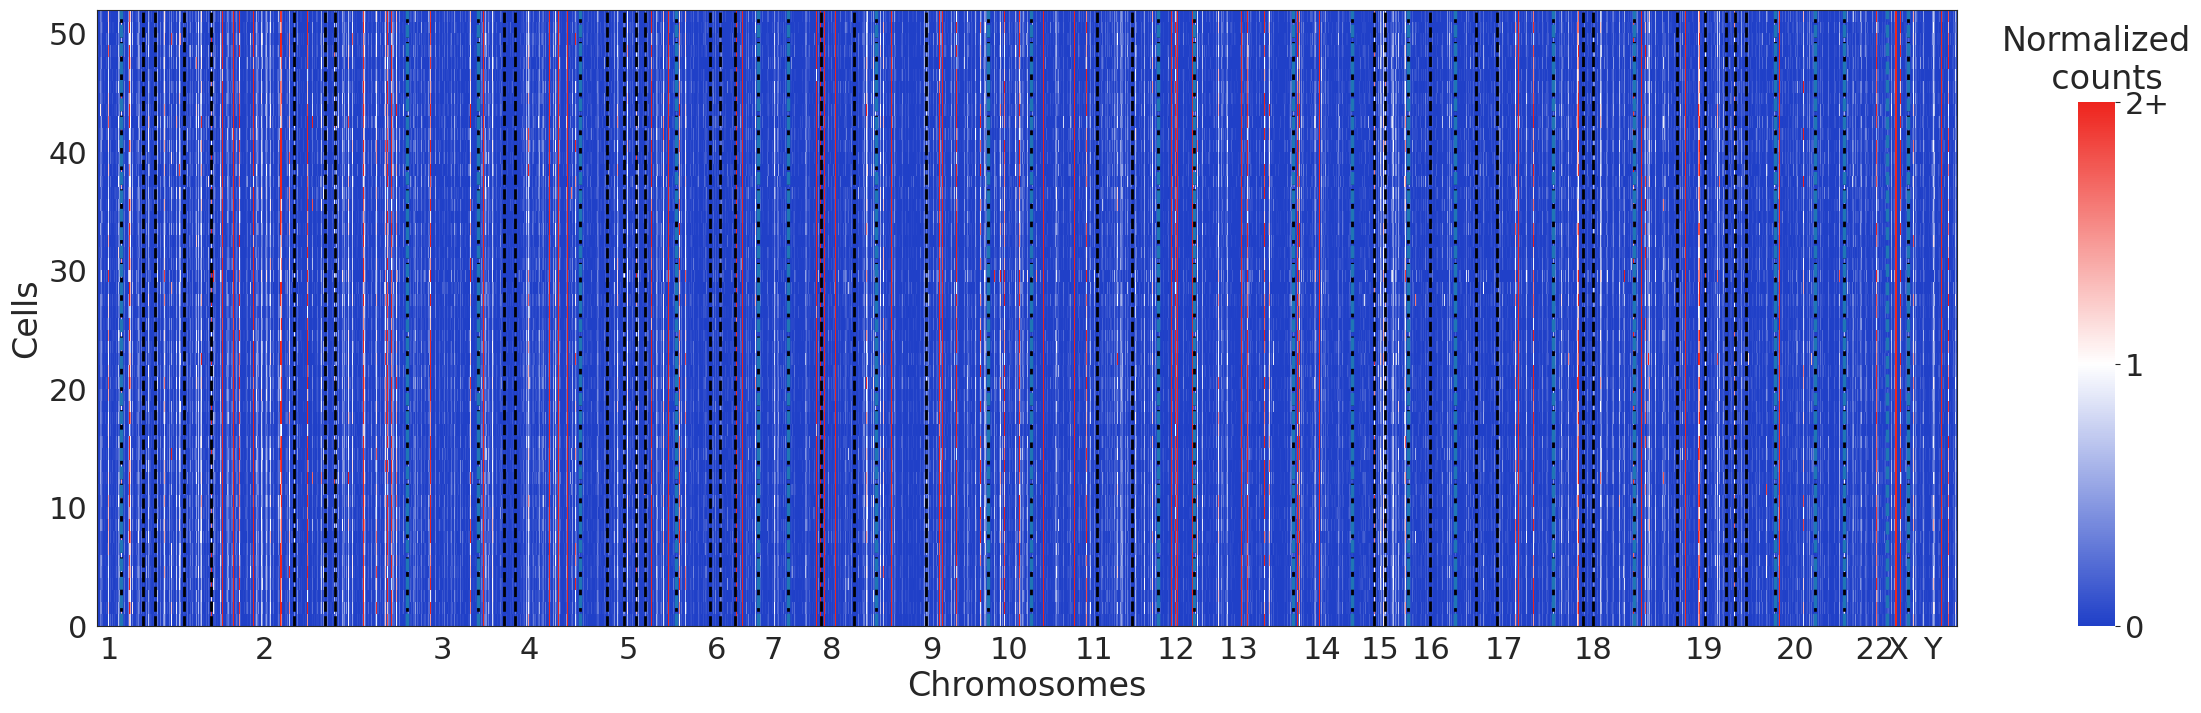

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00681768
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 12.4559
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157,

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 8015 is added to all_max_ids.
Index of the maximum 8412 is added to all_max_ids.
Index of the maximum 9583 is added to all_max_ids.


no breakpoints are found within the interval: (8096,8332)
no breakpoints are found within the interval: (9664,9839)


Index of the maximum 9919 is added to all_max_ids.
Index of the maximum 10824 is added to all_max_ids.
Index of the maximum 11371 is added to all_max_ids.
Index of the maximum 11891 is added to all_max_ids.
Index of the maximum 12319 is added to all_max_ids.
Index of the maximum 13223 is added to all_max_ids.
Index of the maximum 13972 is added to all_max_ids.
Index of the maximum 15274 is added to all_max_ids.
Index of the maximum 15645 is added to all_max_ids.


...

Index of the maximum 2935 is added to all_max_ids.
Index of the maximum 3908 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Index of the maximum 14195 is added to all_max_ids.
Index of the maximum 600 is added to all_max_ids.
Index of the maximum 1063 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 2001 is added to all_max_ids.
Index of the maximum 2111 is added to all_max_ids.
Index of the maximum 2222 is added to all_max_ids.
Index of the maximum 16717 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.


no breakpoints are found within the interval: (3109,3228)


Index of the maximum 3028 is added to all_max_ids.


no breakpoints are found within the interval: (7060,7165)


Index of the maximum 7245 is added to all_max_ids.
Index of the maximum 3736 is added to all_max_ids.
Index of the maximum 12905 is added to all_max_ids.
Found 65 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ordered segmented region sizes to file...
Segmented region sizes are written to file
---------------------------------------------
Detected breakpoints for adata_clusters_sum:
[  218.   422.   529.   800.  1026.  1263.  1818.  2105.  2201.  2311.
  2422.  2859.  3135.  3228.  3508.  3753.  3854.  3936.  4108.  4457.
  4699.  5335.  5562.  5658.  5740.  5872.  6090.  6370.  6675.  7179.
  7445.  7645.  8215.  8612.  9220.  9544.  9783. 10119. 11024. 11571.
 11772. 11878. 12091. 12294. 12519. 12721. 12906. 13105. 13423. 13703.
 13791. 14172. 14395. 14568. 14740. 14827. 15007. 15089. 15171. 15256.
 15474. 15845. 16110. 16700. 16917.]
--------------------------

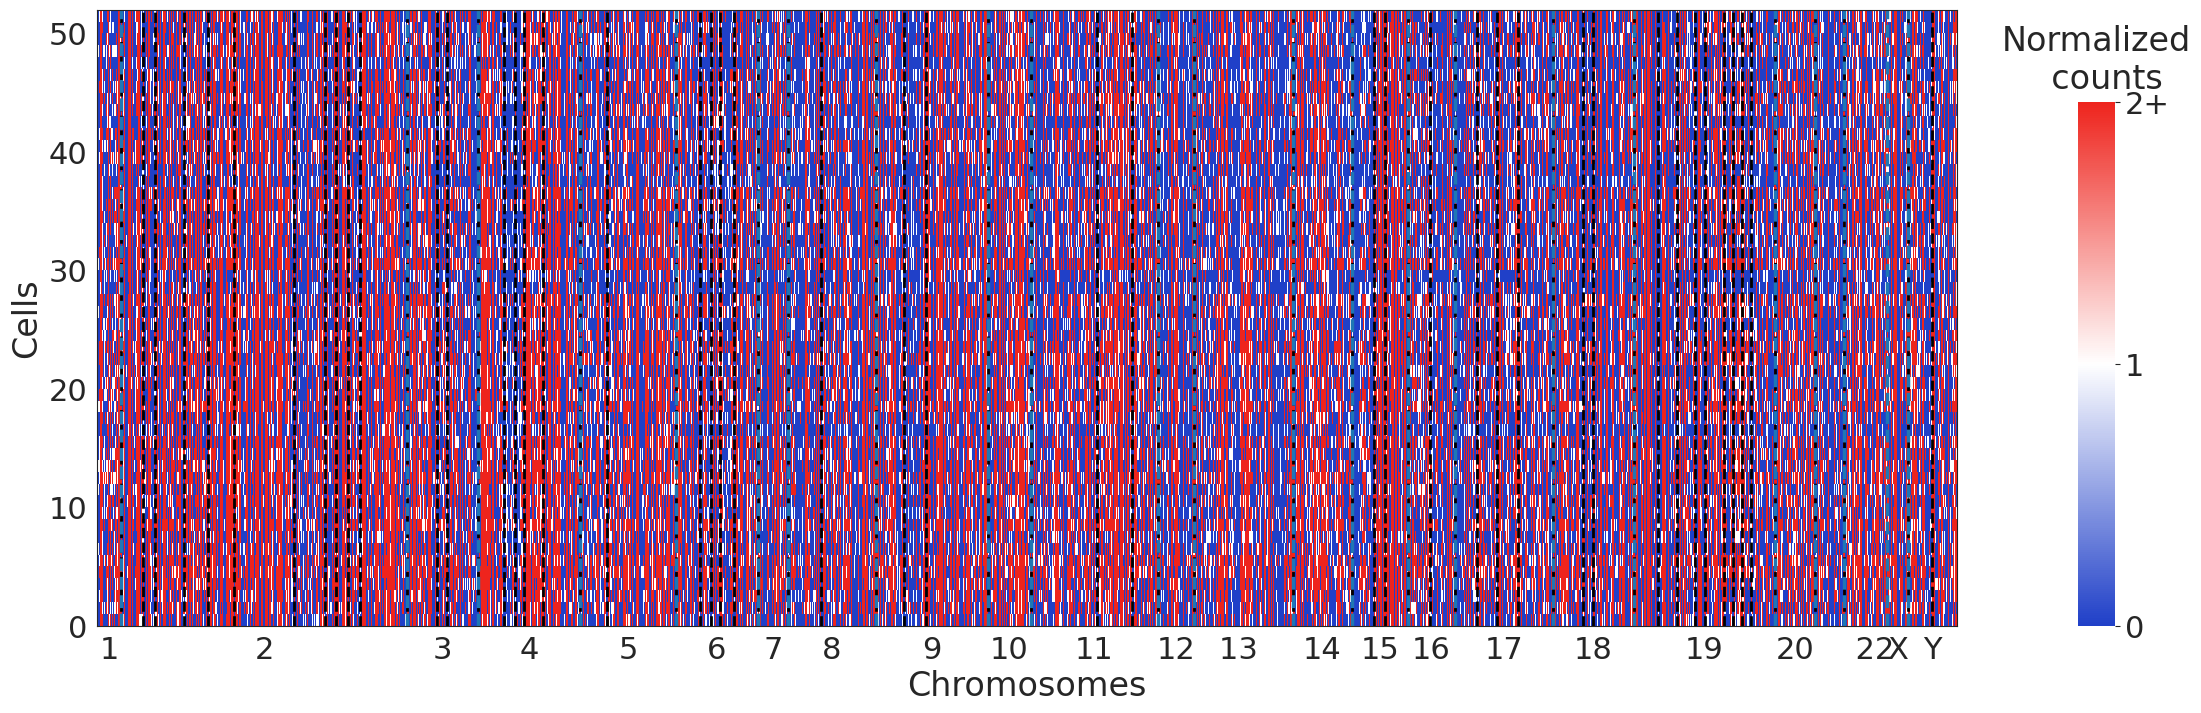

min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.913692
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


---------------------------------------------
Detected breakpoints for clusters_mean_transformed:
An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.674027
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 95.9899
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 2

terminate called after throwing an instance of 'std::logic_error'
  what():  No breakpoints are detected. Perhaps change the configurations and try again.


---------------------------------------------
Detected breakpoints for clusters_sum_transformed:
An error occurred while processing the cluster file: 'segmented_regions'
min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.917301
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176,

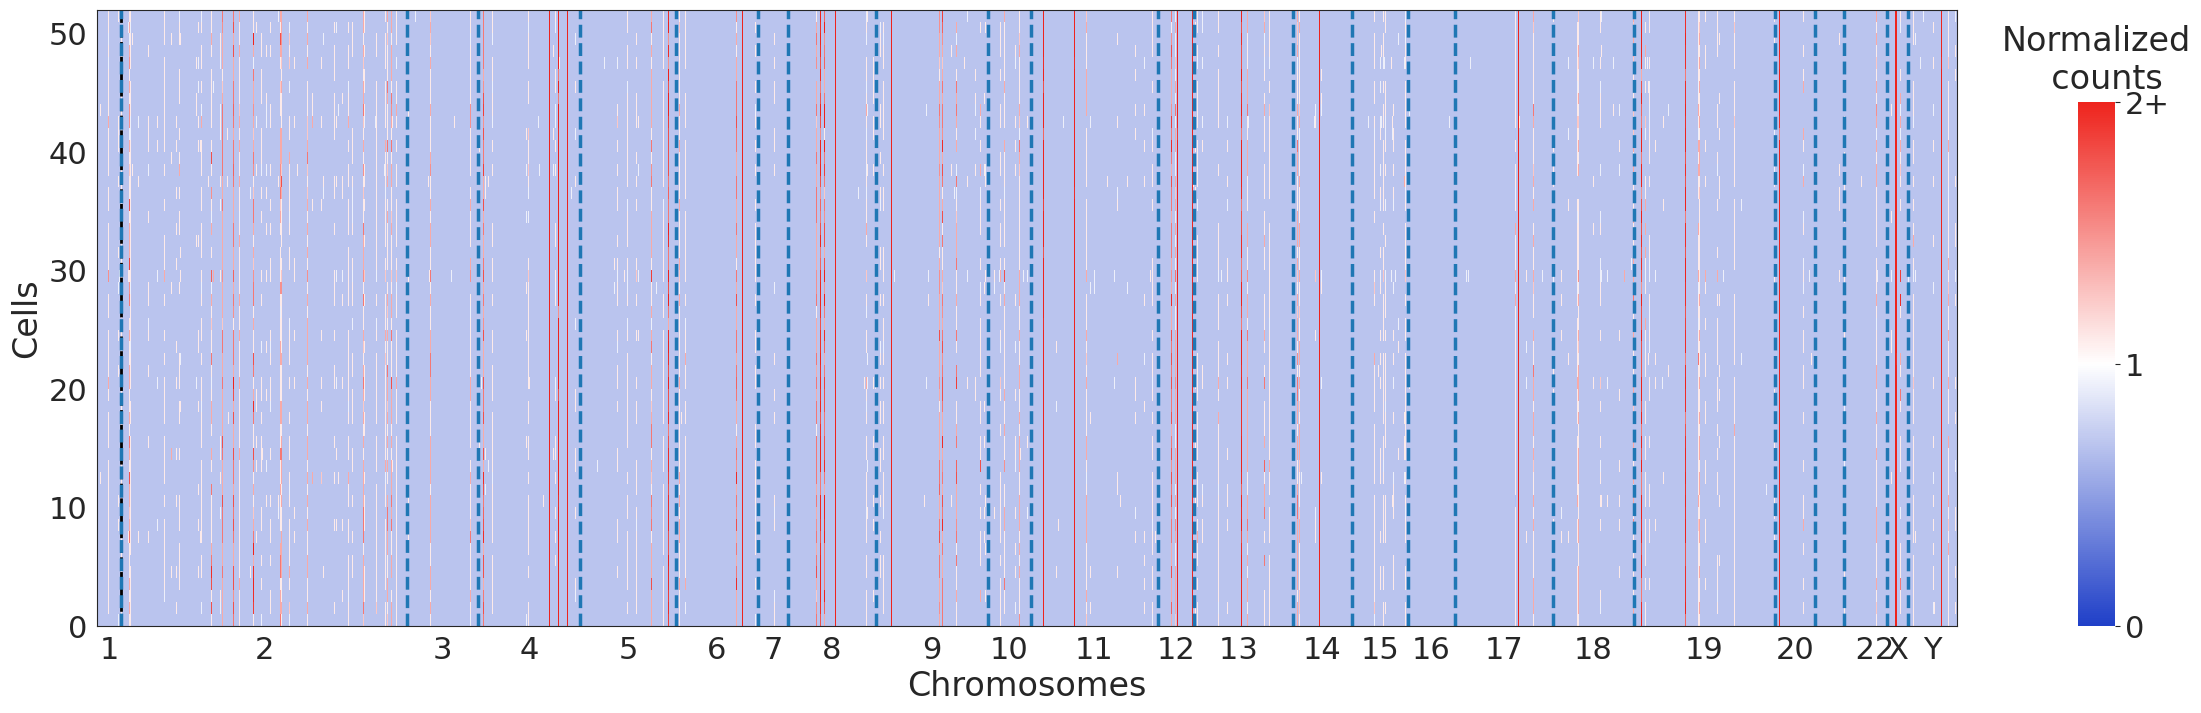

In [5]:
file_list = ['adata_clusters_median', 'adata_clusters_mean', 'adata_clusters_sum', 'clusters_mean_transformed',
             'clusters_sum_transformed', 'clusters_median_transformed']
for cluster_file in file_list:
    for window_size in range(200, 1000, 100):
            try:
                adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
                data = adata.X
                # Run SCICoNE analysis
                bps = sci.detect_breakpoints(data=data, window_size=200, threshold=3, input_breakpoints=chromosome_stops_list)

                print('---------------------------------------------')
                print(f"Detected breakpoints for {cluster_file} with window size: {window_size}:")
                print(bps['segmented_regions'])
                print('---------------------------------------------')
                # Save the matrix plot
                matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
                scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                                chr_stops_dict=chromosome_stops,
                                                cbar_title='Normalized\n  counts', vmax=2, cluster=False)

                # plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
                # plt.close()

                # Learn and save the tree plot
                
                # inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
                # inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

                # tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}.png"
                # Render the tree plot using graphviz's render method

                # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
                # print(f"Tree plot saved to {tree_plot_filename}.png")

            except ValueError as ve:
                print(f"ValueError while processing the cluster file: {ve}")
            except Exception as e:
                print(f"An error occurred while processing the cluster file: {e}")
                continue

In [ ]:
for cluster_file in [cluster_file_1, cluster_file_2,cluster_file_3, cluster_file_4,
                     cluster_file_5, cluster_file_6, cluster_file_7]:
    try:
        adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
        data = adata.X
        # Run SCICoNE analysis
        bps = sci.detect_breakpoints(data=data, window_size=200, threshold=3, input_breakpoints=chromosome_stops_list)

        # Save the matrix plot
        matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
        
        scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                        chr_stops_dict=chromosome_stops,
                                        cbar_title='Normalized\n  counts', vmax=2, cluster=False)

        # plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
        # plt.close()

        # Learn and save the tree plot
        
        # inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
        # inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

        # tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}.png"
        # Render the tree plot using graphviz's render method

        # inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
        # print(f"Tree plot saved to {tree_plot_filename}.png")

    except ValueError as ve:
        print(f"ValueError while processing the cluster file: {ve}")
    except Exception as e:
        print(f"An error occurred while processing the cluster file: {e}")
        continue


min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 15.9831
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276
159, 277
158, 278
157,

no breakpoints are found within the interval: (5971,6090)


Index of the maximum 8015 is added to all_max_ids.
Index of the maximum 8412 is added to all_max_ids.
Index of the maximum 9583 is added to all_max_ids.


no breakpoints are found within the interval: (8096,8332)
no breakpoints are found within the interval: (9664,9839)


Index of the maximum 9919 is added to all_max_ids.
Index of the maximum 10824 is added to all_max_ids.
Index of the maximum 11371 is added to all_max_ids.
Index of the maximum 11891 is added to all_max_ids.
Index of the maximum 12319 is added to all_max_ids.
Index of the maximum 13223 is added to all_max_ids.
Index of the maximum 13972 is added to all_max_ids.
Index of the maximum 15274 is added to all_max_ids.


...

Index of the maximum 16500 is added to all_max_ids.
Index of the maximum 15004 is added to all_max_ids.
Index of the maximum 5540 is added to all_max_ids.
Index of the maximum 3654 is added to all_max_ids.
Index of the maximum 11674 is added to all_max_ids.
Index of the maximum 5456 is added to all_max_ids.
Index of the maximum 11572 is added to all_max_ids.
Index of the maximum 13503 is added to all_max_ids.


no breakpoints are found within the interval: (13304,13423)


Index of the maximum 5683 is added to all_max_ids.
Index of the maximum 9344 is added to all_max_ids.
Index of the maximum 6475 is added to all_max_ids.
Index of the maximum 14900 is added to all_max_ids.
Index of the maximum 7447 is added to all_max_ids.
Index of the maximum 14818 is added to all_max_ids.
Index of the maximum 14627 is added to all_max_ids.
Index of the maximum 14368 is added to all_max_ids.
Index of the maximum 4499 is added to all_max_ids.
Index of the maximum 3553 is added to all_max_ids.


no breakpoints are found within the interval: (3389,3473)


Index of the maximum 852 is added to all_max_ids.
Index of the maximum 12707 is added to all_max_ids.
Index of the maximum 12519 is added to all_max_ids.
Index of the maximum 1618 is added to all_max_ids.
Index of the maximum 1905 is added to all_max_ids.
Index of the maximum 1993 is added to all_max_ids.
Index of the maximum 13591 is added to all_max_ids.
Index of the maximum 12095 is added to all_max_ids.
Index of the maximum 603 is added to all_max_ids.
Index of the maximum 329 is added to all_max_ids.
Index of the maximum 6780 is added to all_max_ids.
Index of the maximum 4655 is added to all_max_ids.
Index of the maximum 4770 is added to all_max_ids.
Index of the maximum 4854 is added to all_max_ids.
Index of the maximum 222 is added to all_max_ids.
Index of the maximum 9020 is added to all_max_ids.
Found 55 breakpoints at try number 1 with threshold 3.
Sorting the all_max_ids...
All max ids are sorted
Writing segmented regions to file...
Segmented regions are written.
Writing ord

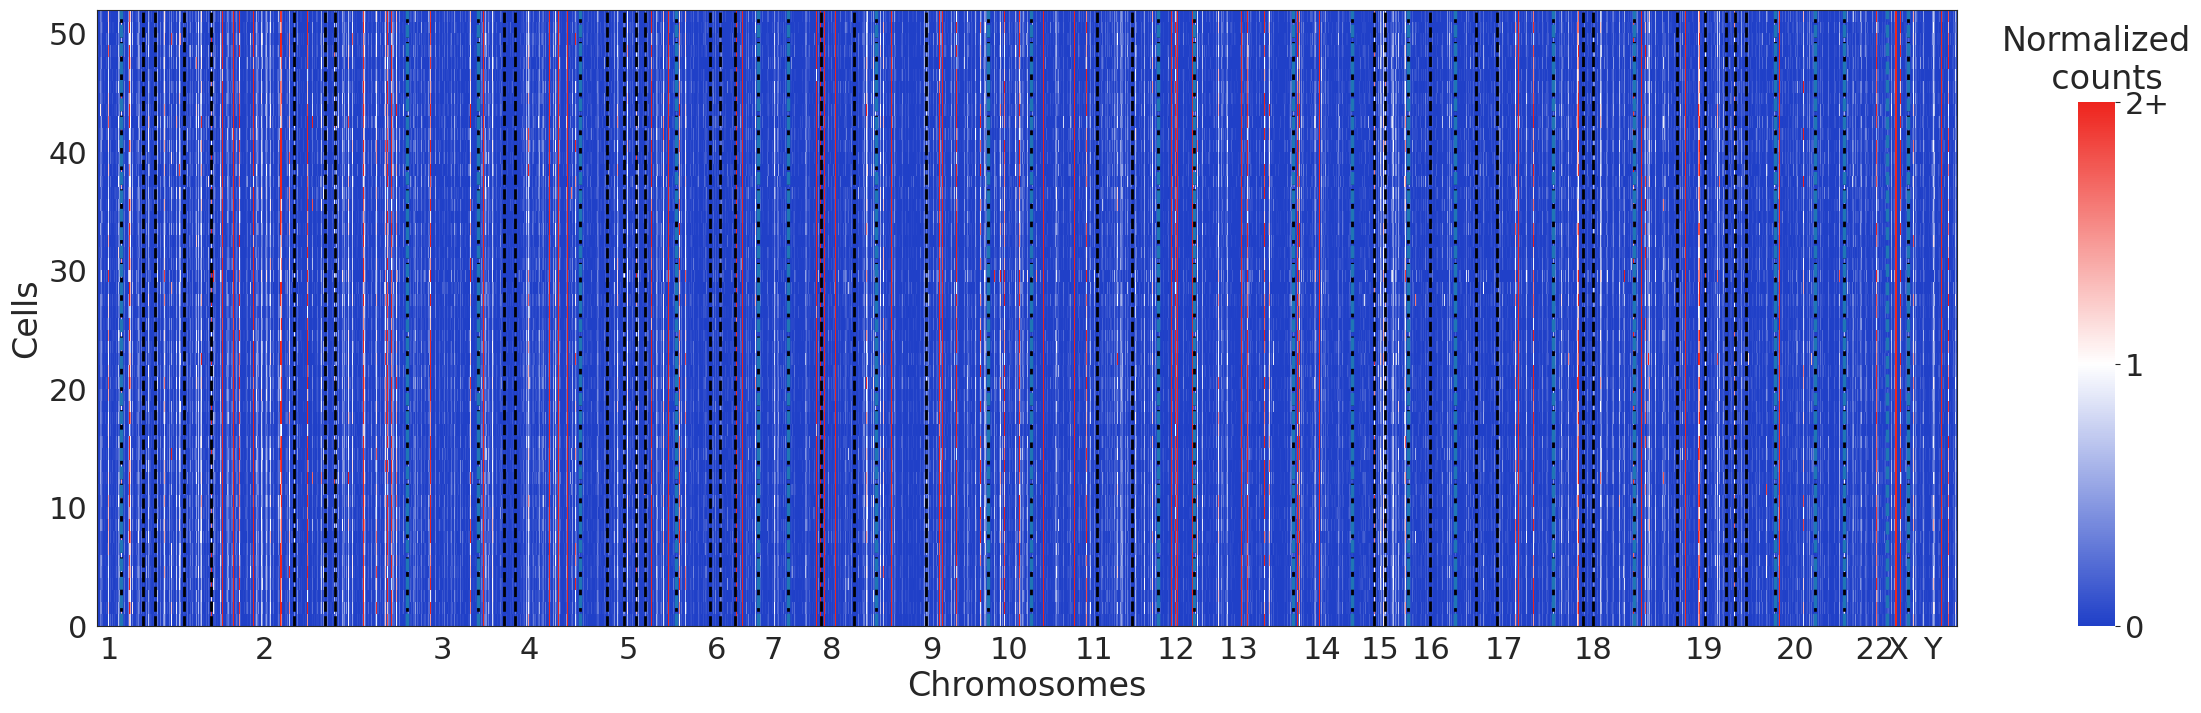

In [6]:
cluster_file = 'adata_clusters_mean'
adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
data = adata.X
# Run SCICoNE analysis
bps = sci.detect_breakpoints(data=data, window_size=200, threshold=3, input_breakpoints=chromosome_stops_list)

        # Save the matrix plot
matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}.png"
scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                chr_stops_dict=chromosome_stops,
                                cbar_title='Normalized\n  counts', vmax=2, cluster=False)


In [ ]:
import matplotlib.pyplot as plt
file_list = ['adata_clusters_median', 'adata_clusters_mean', 'adata_clusters_sum', 'clusters_mean_transformed',
             'clusters_sum_transformed', 'clusters_median_transformed']
# Initialize a dictionary to store results
breakpoints_data = {}

for cluster_file in file_list:
    breakpoints_data[cluster_file] = []
    for window_size in range(200, 800, 100):
        try:
            adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
            data = adata.X
            # Run SCICoNE analysis
            matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
            bps = sci.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list)
            breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
            scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                                chr_stops_dict=chromosome_stops,
                                                cbar_title='Normalized\n  counts', vmax=2, cluster=False)
            plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
            plt.close()

            #Learn and save the tree plot
            
            inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
            inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

            tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
            #Render the tree plot using graphviz's render method

            inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
            print(f"Tree plot saved to {tree_plot_filename}.png")

        except Exception as e:
            print(f"Error processing {cluster_file} with window size {window_size}: {e}")
            continue

# Plot the results
for cluster_file, data_points in breakpoints_data.items():
    if data_points:
        window_sizes, breakpoints_counts = zip(*data_points)
        plt.figure(figsize=(8, 6))
        plt.plot(window_sizes, breakpoints_counts, marker='o', label=cluster_file)
        plt.title(f'Breakpoints Detected vs Window Size for {cluster_file}')
        plt.xlabel('Window Size')
        plt.ylabel('Number of Breakpoints Detected')
        plt.legend()
        plt.grid(True)
        plt.show()
        #save plots
        plt.savefig(f"{temporary_outpath}/breakpoints_plot_{cluster_file}.png", dpi=300, bbox_inches='tight')



min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 25
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00444591
n_regions: 25


KeyboardInterrupt: 

In [14]:

cluster_file = 'adata_clusters_mean'
window_size = 500
#for window_size in range(200, 800, 100):
try:
    adata = anndata.read_h5ad(f'{adatas_path}/{cluster_file}.h5ad')
    data = adata.X
    # Run SCICoNE analysis
    matrix_plot_filename = f"{temporary_outpath}/matrix_plot_{cluster_file}_{window_size}.png"
    bps = sci.detect_breakpoints(data=data, window_size=window_size, threshold=3, input_breakpoints=chromosome_stops_list)
    #breakpoints_data[cluster_file].append((window_size, len(bps['segmented_regions'])))
    scicone.plotting.plot_matrix(data, bps = bps['segmented_regions'],
                                        chr_stops_dict=chromosome_stops,
                                        cbar_title='Normalized\n  counts', vmax=2, cluster=False)
    plt.savefig(matrix_plot_filename, dpi=300, bbox_inches='tight')
    plt.close()

    #Learn and save the tree plot
    
    inferred_tree = sci.learn_tree(data, bps["segmented_region_sizes"], n_reps = 4, seed = seed, max_tries = 1)
    inferred_tree.plot_tree(gene_labels=True, node_labels=True, node_sizes=True, event_fontsize=8, nodesize_fontsize=10)

    tree_plot_filename = f"{temporary_outpath}/tree_plot_{cluster_file}_{window_size}.png"
    #Render the tree plot using graphviz's render method

    inferred_tree.render(tree_plot_filename, format='png', dpi = 600, cleanup=True)
    print(f"Tree plot saved to {tree_plot_filename}.png")

except Exception as e:
    print(f"Error processing {cluster_file} with window size {window_size}: {e}")


min_cells is not specified, 4 cells are going to be considered
Reading provided breakpoints: PYSCICONETEMPbp_pre_input_breakpoints_file.txt
Done.
Reading the input matrix: PYSCICONETEMPbp_bp_detection.txt
Input matrix is read.
Computing the probability of a region being a breakpoint...
Method of moments estimated nu=0.00814777
n_regions: 25
Combining scores...
Combining scores...
Done.
Computed probabilities for all regions.
Adding in known breakpoints...
Max sp: 0.00245767
217, 219
216, 220
215, 221
214, 222
213, 223
212, 224
211, 225
210, 226
209, 227
208, 228
207, 229
206, 230
205, 231
204, 232
203, 233
202, 234
201, 235
200, 236
199, 237
198, 238
197, 239
196, 240
195, 241
194, 242
193, 243
192, 244
191, 245
190, 246
189, 247
188, 248
187, 249
186, 250
185, 251
184, 252
183, 253
182, 254
181, 255
180, 256
179, 257
178, 258
177, 259
176, 260
175, 261
174, 262
173, 263
172, 264
171, 265
170, 266
169, 267
168, 268
167, 269
166, 270
165, 271
164, 272
163, 273
162, 274
161, 275
160, 276

==17732==ERROR: AddressSanitizer: heap-buffer-overflow on address 0x7f93f797f7f8 at pc 0x5608c3aed1e7 bp 0x7ffeffcc67d0 sp 0x7ffeffcc67c0
WRITE of size 8 at 0x7f93f797f7f8 thread T0
    #0 0x5608c3aed1e6 in main (/home/andress/pylabs/SCICoNE_lab/build/breakpoint_detection+0x1d1e6) (BuildId: 955cdf7c3e082f240cb00b4ce9cd736c84f904f9)
    #1 0x7f93fad811c9  (/lib/x86_64-linux-gnu/libc.so.6+0x2a1c9) (BuildId: 42c84c92e6f98126b3e2230ebfdead22c235b667)
    #2 0x7f93fad8128a in __libc_start_main (/lib/x86_64-linux-gnu/libc.so.6+0x2a28a) (BuildId: 42c84c92e6f98126b3e2230ebfdead22c235b667)
    #3 0x5608c3ae48f4 in _start (/home/andress/pylabs/SCICoNE_lab/build/breakpoint_detection+0x148f4) (BuildId: 955cdf7c3e082f240cb00b4ce9cd736c84f904f9)

0x7f93f797f7f8 is located 8 bytes before 262144-byte region [0x7f93f797f800,0x7f93f79bf800)
allocated by thread T0 here:
    #0 0x7f93fb4fd548 in operator new(unsigned long) ../../../../src/libsanitizer/asan/asan_new_delete.cpp:95
    #1 0x5608c3b32c0b in s